# Demo Notebook

In [1]:
import numpy as np
import torch
import IPython.display as ipd
import matplotlib.pyplot as plt
import librosa

from df0.dyin import dYIN
from df0.dswipe import dSWIPE

## 1. Load audio

In [2]:
# load audio
fn_wav = librosa.ex("trumpet")
x, fs = librosa.load(fn_wav, sr=16000)
x_duration = len(x) / fs
hop_size = 160
x = torch.from_numpy(x)
ipd.Audio(x, rate=fs)

/home/stst@alabsad.fau.de/miniconda3/envs/df0/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def visualize_predictions(logits, probs, pred_hz, t, f0_classes_hz):
    _, ax = plt.subplots(1, 3, figsize=(13, 2.5))

    # logits
    im0 = ax[0].pcolormesh(t, f0_classes_hz, logits.T, cmap="gray_r")
    ax[0].set_ylim((55, 880))
    ax[0].set_yticks([55, 220, 440, 660, 880])
    ax[0].set_xlim((0, x_duration))
    ax[0].set_ylabel("Frequency (Hz)")
    ax[0].set_xlabel("Time (seconds)")
    ax[0].set_title("Unnormalized F0 Logits")

    # salience representation
    im1 = ax[1].pcolormesh(t, f0_classes_hz, probs.T, cmap="gray_r")
    ax[1].set_ylim((55, 880))
    ax[1].set_yticks([55, 220, 440, 660, 880])
    ax[1].set_xlim((0, x_duration))
    ax[1].set_ylabel("Frequency (Hz)")
    ax[1].set_xlabel("Time (seconds)")
    ax[1].set_title("F0 Salience Representation")

    # colorbars
    plt.sca(ax[0])
    plt.colorbar(im0, aspect=20)

    plt.sca(ax[1])
    plt.colorbar(im1, aspect=20)

    # predictions
    ax[2].plot(t, pred_hz, color="r", markersize=4, marker=".", linestyle="")
    ax[2].set_ylim((55, 880))
    ax[2].set_yticks([55, 220, 440, 660, 880])
    ax[2].set_xlim((0, x_duration))
    ax[2].set_ylabel("Frequency (Hz)")
    ax[2].set_xlabel("Time (seconds)")
    ax[2].set_title("F0 Predictions")

    plt.tight_layout()

## 2. dYIN

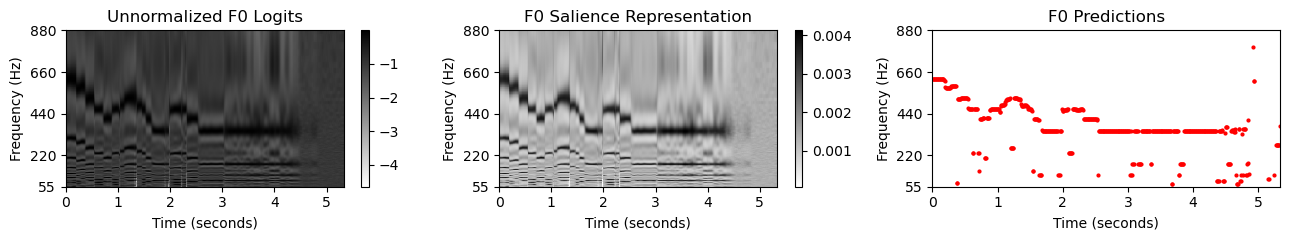

In [4]:
dyin_config = {
    "fs": fs,
    "frame_size": 1600,
    "hop_size": hop_size,
    "f0_min": 55.0,
    "f0_max": 3520.0,
    "f0_r_cent": 10.0,
    "f0_selection_strategy": "argmax",
}

dyin = dYIN(**dyin_config)

out = dyin(x)

t = np.arange(out["f0_hz"].numel()) * hop_size / fs
f0_classes_hz = dyin.f0_classes_hz.numpy()

visualize_predictions(out["logits"].numpy(), out["probs"].numpy(), out["f0_hz"].numpy(), t, f0_classes_hz)

## 3. dSWIPE

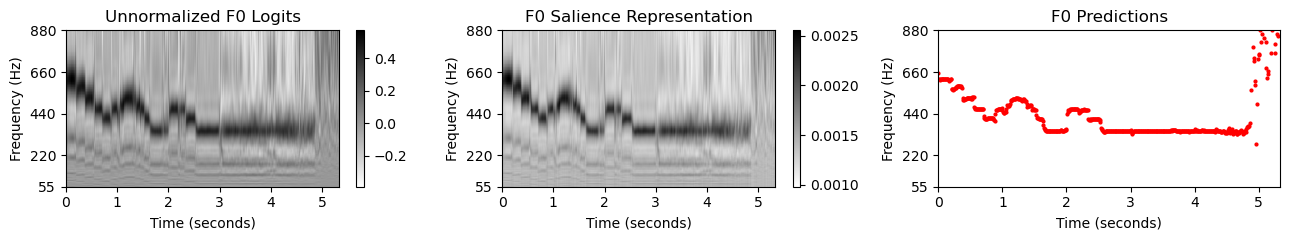

In [5]:
dswipe_config = {
    "fs": fs,
    "hop_size": hop_size,
    "f0_min": 55.0,
    "f0_max": 3520.0,
    "f0_r_cent": 10.0,
    "f0_selection_strategy": "argmax",
    "template_params": {
        "training_mode": None
    }
}

dswipe = dSWIPE(**dswipe_config)

out = dswipe(x)

t = np.arange(out["f0_hz"].numel()) * hop_size / fs
f0_classes_hz = dswipe.f0_classes_hz.numpy()

visualize_predictions(out["logits"].detach().numpy(), out["probs"].detach().numpy(), out["f0_hz"].detach().numpy(), t, f0_classes_hz)

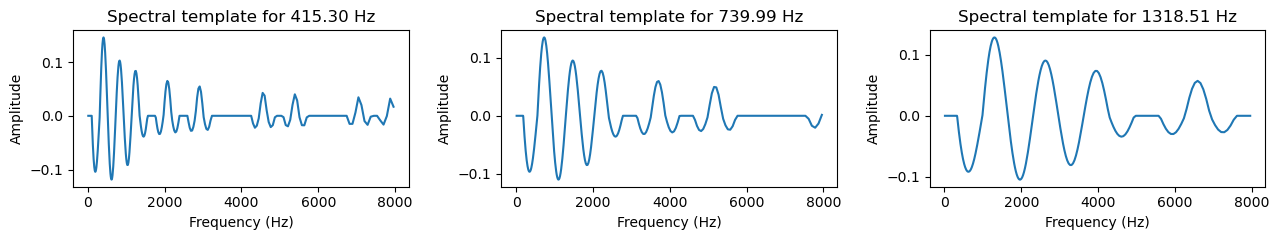

In [6]:
# plot templates
templates = dswipe.templates.detach()
f_erb_hz = dswipe.f_erb_hz

fig, ax = plt.subplots(1, 3, figsize=(13, 2.5))

for i, idx in enumerate([350, 450, 550]):
    ax[i].plot(f_erb_hz, templates[idx])
    ax[i].set_ylabel("Amplitude")
    ax[i].set_xlabel("Frequency (Hz)")
    ax[i].set_title(f"Spectral template for {f0_classes_hz[idx]:.2f} Hz")

plt.tight_layout()